In [4]:
import joblib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
import os
from datetime import datetime
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
# 2.1 Load scalers
print("Loading scalers...")
scaler = joblib.load('./models_saved/scaler.pkl')
robust_scaler = joblib.load('./models_saved/robust_scaler.pkl')
print("✓ Scalers loaded")

Loading scalers...
✓ Scalers loaded


In [4]:
# 2.2 Load feature columns
print("\nLoading feature columns...")
with open('./models_saved/feature_columns.json', 'r') as f:
    feature_columns = json.load(f)
print(f"✓ Feature columns loaded: {len(feature_columns)} features")

# 2.3 Load model metadata
print("\nLoading model metadata...")
with open('./models_saved/model_metadata.json', 'r') as f:
    metadata = json.load(f)
print("✓ Model metadata loaded:")
print(f"  - Best Model: {metadata['best_model']}")
print(f"  - F1 Score: {metadata['best_f1_score']:.4f}")

# 2.4 Load the best model
print("\nLoading best model...")
best_model = joblib.load('./models_saved/best_model.pkl')
print(f"✓ Best model loaded: {type(best_model).__name__}")


Loading feature columns...
✓ Feature columns loaded: 24 features

Loading model metadata...
✓ Model metadata loaded:
  - Best Model: XGBoost
  - F1 Score: 0.6940

Loading best model...
✓ Best model loaded: str


In [5]:
# 2.5 Load all models (optional)
print("\nLoading all models...")
loaded_models = {}
model_names = ['logistic_regression', 'decision_tree', 'svm', 'random_forest', 
               'gradient_boosting', 'xgboost', 'lightgbm', 'voting_ensemble']

for name in model_names:
    try:
        model = joblib.load(f'./models_saved/{name}.pkl')
        loaded_models[name] = model
        print(f"  ✓ {name} loaded")
    except Exception as e:
        print(f"  ✗ Error loading {name}: {str(e)}")

print("\nAll models loaded successfully!")


Loading all models...
  ✓ logistic_regression loaded
  ✓ decision_tree loaded
  ✓ svm loaded
  ✓ random_forest loaded
  ✓ gradient_boosting loaded
  ✓ xgboost loaded
  ✓ lightgbm loaded
  ✓ voting_ensemble loaded

All models loaded successfully!


## Prepare Test Data

In [6]:
# 3.1 Load test data
print("Loading test data...")
X_test_orig = pd.read_csv('./data/processed/X_test.csv')
X_test_scaled = pd.read_csv('./data/processed/X_test_scaled.csv')
y_test = pd.read_csv('./data/processed/y_test.csv').squeeze()

print(f"✓ Test data loaded:")
print(f"  - Test samples: {len(X_test_orig)}")
print(f"  - Features: {X_test_orig.shape[1]}")
print(f"  - Fraud cases: {y_test.sum()}")

# 3.2 Load training data for comparison (optional)
print("\nLoading training data...")
X_train_orig = pd.read_csv('./data/processed/X_train.csv')
X_train_scaled = pd.read_csv('./data/processed/X_train_scaled.csv')
y_train = pd.read_csv('./data/processed/y_train.csv').squeeze()

print(f"✓ Training data loaded:")
print(f"  - Train samples: {len(X_train_orig)}")
print(f"  - Fraud cases: {y_train.sum()}")

# 3.3 Verify feature alignment
print("\nVerifying feature alignment...")
if list(X_test_orig.columns) == feature_columns:
    print("✓ Features align with saved feature columns")
else:
    print("Warning: Features do not match saved feature columns")
    print(f"  - Expected: {len(feature_columns)} features")
    print(f"  - Found: {X_test_orig.shape[1]} features")

Loading test data...
✓ Test data loaded:
  - Test samples: 1272524
  - Features: 24
  - Fraud cases: 1643

Loading training data...
✓ Training data loaded:
  - Train samples: 5090096
  - Fraud cases: 6570

Verifying feature alignment...
✓ Features align with saved feature columns


# COMPREHENSIVE MODEL TESTING

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, matthews_corrcoef)
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
def evaluate_model_detailed(model, X_test, y_test, model_name="Model", 
                           threshold=0.5):
    """
    Detailed model evaluation with multiple metrics
    """
    # Get predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    if y_pred_proba is not None:
        # Apply threshold for binary predictions
        y_pred = (y_pred_proba >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = None
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'threshold': threshold
    }
    
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    metrics['true_negatives'] = int(tn)
    metrics['false_positives'] = int(fp)
    metrics['false_negatives'] = int(fn)
    metrics['true_positives'] = int(tp)
    metrics['confusion_matrix'] = cm
    
    # Additional metrics
    metrics['precision_neg'] = tn / (tn + fn) if (tn + fn) > 0 else 0
    metrics['recall_neg'] = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return metrics, y_pred, y_pred_proba

In [15]:
# 4.2 TEST ALL MODELS (CORRECTED)
print("📊 TESTING ALL MODELS")
all_test_results = {}

# Model type mapping
model_type_mapping = {
    'logistic_regression': 'linear',
    'svm': 'linear',
    'calibratedclassifiercv': 'linear',
    'decision_tree': 'tree',
    'random_forest': 'tree',
    'gradient_boosting': 'tree',
    'xgboost': 'tree',
    'lightgbm': 'tree',
    'voting_ensemble': 'tree'
}

for model_name, model in loaded_models.items():
    print(f"\n🔍 Evaluating {model_name}...")
    
    # Determine which test data to use based on model type
    model_type = model_type_mapping.get(model_name, 'tree')  # Default to tree
    
    if model_type == 'linear':
        X_test_data = X_test_scaled
        print(f"  → Using SCALED data")
    else:
        X_test_data = X_test_orig
        print(f"  → Using ORIGINAL data")
    
    try:
        metrics, pred, proba = evaluate_model_detailed(
            model, X_test_data, y_test, model_name
        )
        all_test_results[model_name] = metrics
        
        print(f"  - F1 Score:  {metrics['f1']:.4f}")
        print(f"  - Precision: {metrics['precision']:.4f}")
        print(f"  - Recall:    {metrics['recall']:.4f}")
        print(f"  - ROC AUC:   {metrics.get('roc_auc', 'N/A'):.4f}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        # Try the alternative data type
        print(f"  🔄 Trying alternative data type...")
        
        try:
            # If scaled failed, try original and vice versa
            if model_type == 'linear':
                X_test_alt = X_test_orig
            else:
                X_test_alt = X_test_scaled
            
            metrics, pred, proba = evaluate_model_detailed(
                model, X_test_alt, y_test, model_name
            )
            all_test_results[model_name] = metrics
            print(f"  ✓ Evaluation completed with alternative data")
            print(f"  - F1 Score:  {metrics['f1']:.4f}")
            
        except Exception as e2:
            print(f"  ✗ Both attempts failed: {str(e2)}")

# Print summary
print("📊 ALL MODELS - PERFORMANCE SUMMARY")

print(f"\n{'Model':<30} {'F1 Score':<15} {'Precision':<15} {'Recall':<15}")

for model_name, metrics in all_test_results.items():
    print(f"{model_name:<30} {metrics['f1']:<15.4f} {metrics['precision']:<15.4f} {metrics['recall']:<15.4f}")

📊 TESTING ALL MODELS

🔍 Evaluating logistic_regression...
  → Using SCALED data
  - F1 Score:  0.0474
  - Precision: 0.0243
  - Recall:    0.9945
  - ROC AUC:   0.9949

🔍 Evaluating decision_tree...
  → Using ORIGINAL data
  - F1 Score:  0.1035
  - Precision: 0.0551
  - Recall:    0.8576
  - ROC AUC:   0.9286

🔍 Evaluating svm...
  → Using SCALED data
  - F1 Score:  0.4757
  - Precision: 0.9105
  - Recall:    0.3220
  - ROC AUC:   0.9948

🔍 Evaluating random_forest...
  → Using ORIGINAL data
  - F1 Score:  0.4927
  - Precision: 0.3494
  - Recall:    0.8357
  - ROC AUC:   0.9951

🔍 Evaluating gradient_boosting...
  → Using ORIGINAL data
  - F1 Score:  0.6097
  - Precision: 0.6809
  - Recall:    0.5520
  - ROC AUC:   0.9021

🔍 Evaluating xgboost...
  → Using ORIGINAL data
  - F1 Score:  0.6940
  - Precision: 0.6001
  - Recall:    0.8229
  - ROC AUC:   0.9982

🔍 Evaluating lightgbm...
  → Using ORIGINAL data
  - F1 Score:  0.1707
  - Precision: 0.0938
  - Recall:    0.9550
  - ROC AUC:   

In [17]:
# 4.2 TEST ALL MODELS (CORRECTED)
print("TESTING ALL MODELS")

all_test_results = {}

# Model type mapping
model_type_mapping = {
    'logistic_regression': 'linear',
    'svm': 'linear',
    'calibratedclassifiercv': 'linear',
    'decision_tree': 'tree',
    'random_forest': 'tree',
    'gradient_boosting': 'tree',
    'xgboost': 'tree',
    'lightgbm': 'tree',
    'voting_ensemble': 'tree'
}

for model_name, model in loaded_models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Determine which test data to use based on model type
    model_type = model_type_mapping.get(model_name, 'tree')  # Default to tree
    
    if model_type == 'linear':
        X_test_data = X_test_scaled
        print(f"  → Using SCALED data")
    else:
        X_test_data = X_test_orig
        print(f"  → Using ORIGINAL data")
    
    try:
        metrics, pred, proba = evaluate_model_detailed(
            model, X_test_data, y_test, model_name
        )
        all_test_results[model_name] = metrics
        
        print(f"  - F1 Score:  {metrics['f1']:.4f}")
        print(f"  - Precision: {metrics['precision']:.4f}")
        print(f"  - Recall:    {metrics['recall']:.4f}")
        print(f"  - ROC AUC:   {metrics.get('roc_auc', 'N/A'):.4f}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        # Try the alternative data type
        print(f"  Trying alternative data type...")
        
        try:
            # If scaled failed, try original and vice versa
            if model_type == 'linear':
                X_test_alt = X_test_orig
            else:
                X_test_alt = X_test_scaled
            
            metrics, pred, proba = evaluate_model_detailed(
                model, X_test_alt, y_test, model_name
            )
            all_test_results[model_name] = metrics
            print(f"  ✓ Evaluation completed with alternative data")
            print(f"  - F1 Score:  {metrics['f1']:.4f}")
            
        except Exception as e2:
            print(f"  ✗ Both attempts failed: {str(e2)}")

# Print summary
print("\n" + "="*80)
print("ALL MODELS - PERFORMANCE SUMMARY")
print("="*80)

print(f"\n{'Model':<30} {'F1 Score':<15} {'Precision':<15} {'Recall':<15}")
print("-"*75)

for model_name, metrics in all_test_results.items():
    print(f"{model_name:<30} {metrics['f1']:<15.4f} {metrics['precision']:<15.4f} {metrics['recall']:<15.4f}")

TESTING ALL MODELS

Evaluating logistic_regression...
  → Using SCALED data
  - F1 Score:  0.0474
  - Precision: 0.0243
  - Recall:    0.9945
  - ROC AUC:   0.9949

Evaluating decision_tree...
  → Using ORIGINAL data
  - F1 Score:  0.1035
  - Precision: 0.0551
  - Recall:    0.8576
  - ROC AUC:   0.9286

Evaluating svm...
  → Using SCALED data
  - F1 Score:  0.4757
  - Precision: 0.9105
  - Recall:    0.3220
  - ROC AUC:   0.9948

Evaluating random_forest...
  → Using ORIGINAL data
  - F1 Score:  0.4927
  - Precision: 0.3494
  - Recall:    0.8357
  - ROC AUC:   0.9951

Evaluating gradient_boosting...
  → Using ORIGINAL data
  - F1 Score:  0.6097
  - Precision: 0.6809
  - Recall:    0.5520
  - ROC AUC:   0.9021

Evaluating xgboost...
  → Using ORIGINAL data
  - F1 Score:  0.6940
  - Precision: 0.6001
  - Recall:    0.8229
  - ROC AUC:   0.9982

Evaluating lightgbm...
  → Using ORIGINAL data
  - F1 Score:  0.1707
  - Precision: 0.0938
  - Recall:    0.9550
  - ROC AUC:   0.9981

Evaluati

GENERATING CONFUSION MATRICES

🔍 Plotting best model confusion matrix...
  ✓ Confusion matrix saved to ./reports/figures/best_model_confusion_matrix.png


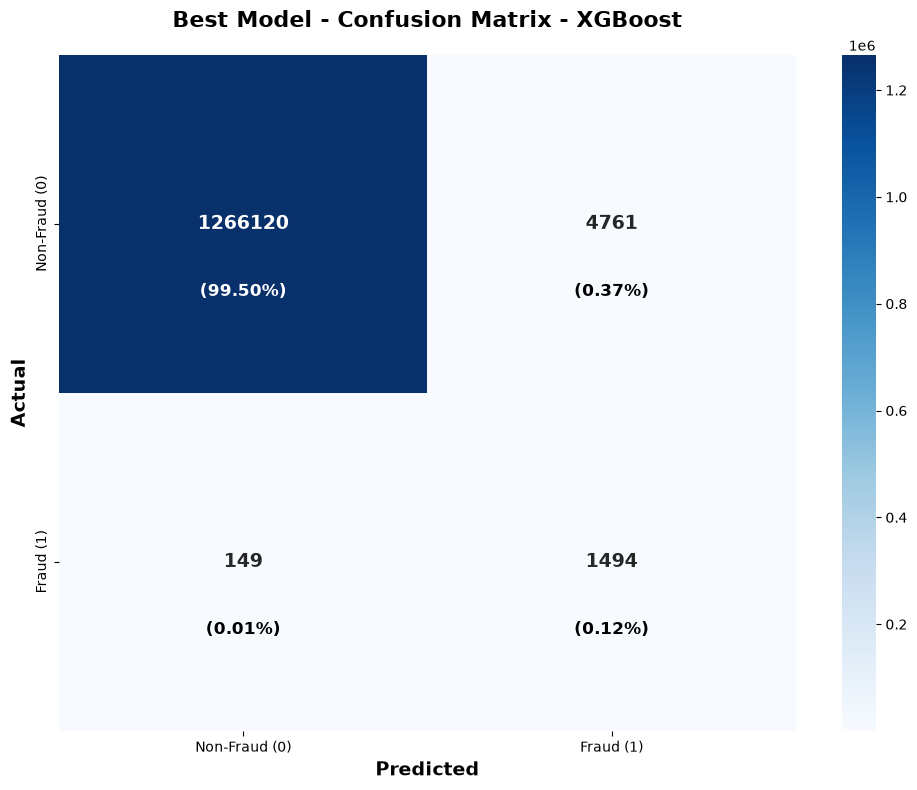


🔍 Plotting confusion matrices for all models...
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/logistic_regression_confusion_matrix.png
  ✓ logistic_regression confusion matrix saved
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/decision_tree_confusion_matrix.png
  ✓ decision_tree confusion matrix saved
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/svm_confusion_matrix.png
  ✓ svm confusion matrix saved
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/random_forest_confusion_matrix.png
  ✓ random_forest confusion matrix saved
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/gradient_boosting_confusion_matrix.png
  ✓ gradient_boosting confusion matrix saved
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/xgboost_confusion_matrix.png
  ✓ xgboost confusion matrix saved
  ✓ Confusion matrix saved to ./reports/figures/confusion_matrices/lightgbm_confusion_matrix.png
  ✓ ligh

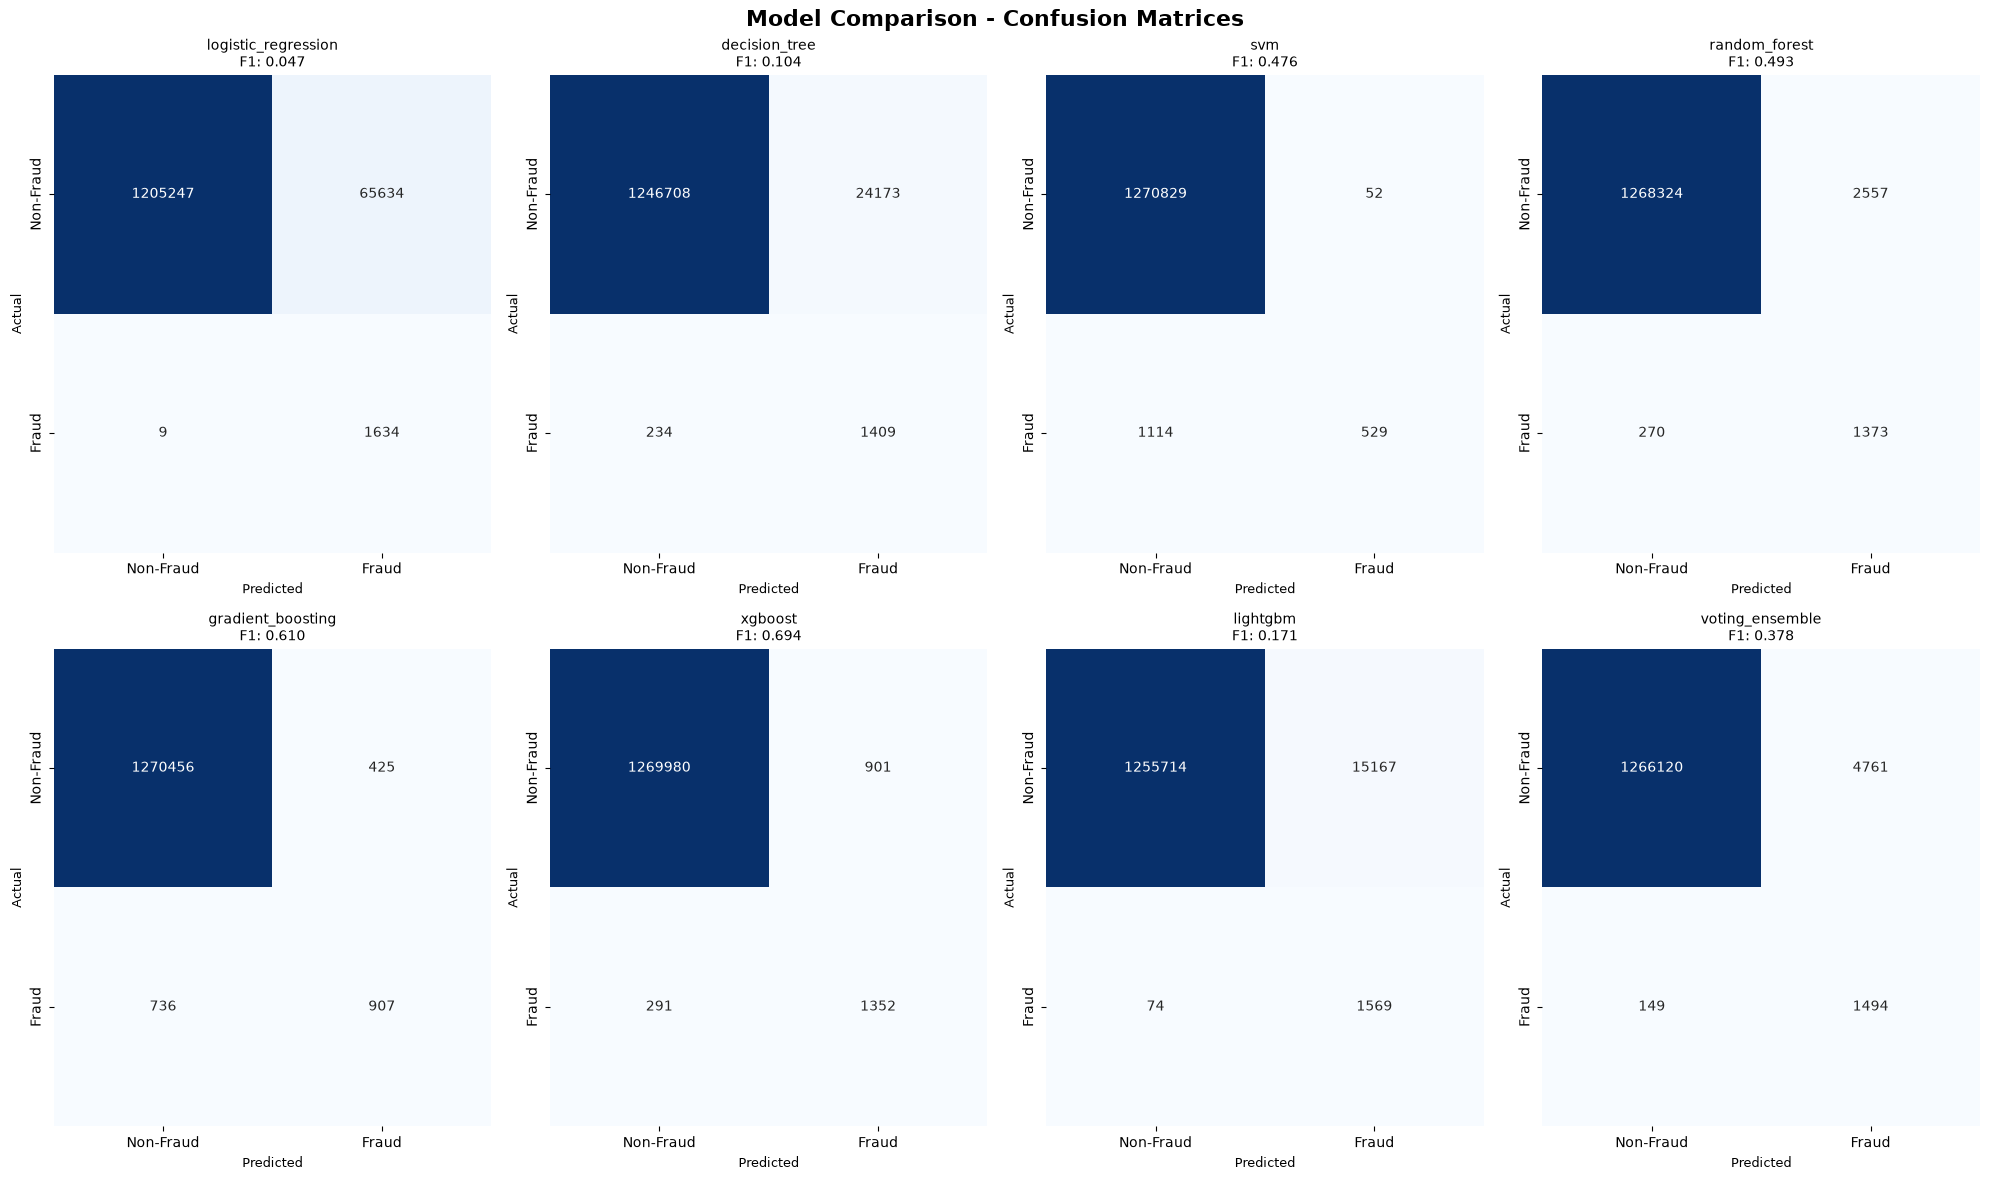

✓ Combined confusion matrix saved to ./reports/figures/confusion_matrices_comparison.png

All confusion matrices generated successfully!


In [22]:
# CONFUSION MATRIX VISUALIZATION

def plot_confusion_matrix(cm, model_name, title_prefix="Confusion Matrix", save_path=None):
    """
    Plot confusion matrix with annotations and percentages
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap with custom colors
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
                yticklabels=['Non-Fraud (0)', 'Fraud (1)'],
                ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
    
    # Add percentage annotations
    total = np.sum(cm)
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            color = 'white' if cm[i, j] > total/4 else 'black'
            ax.text(j + 0.5, i + 0.7, f'({pct:.2f}%)', 
                   ha='center', va='center', color=color, fontsize=12, weight='bold')
    
    ax.set_xlabel('Predicted', fontsize=14, weight='bold')
    ax.set_ylabel('Actual', fontsize=14, weight='bold')
    ax.set_title(f'{title_prefix} - {model_name}', fontsize=16, weight='bold', pad=20)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Confusion matrix saved to {save_path}")
    
    return fig

# 5.1 Plot confusion matrix for best model

print("GENERATING CONFUSION MATRICES")

# Create directories
os.makedirs('./reports/figures/confusion_matrices', exist_ok=True)

# Plot best model confusion matrix
print("\n🔍 Plotting best model confusion matrix...")
if 'best_metrics' in locals():
    cm_best = metrics['confusion_matrix']
    fig = plot_confusion_matrix(
        cm_best, 
        metadata['best_model'], 
        "Best Model - Confusion Matrix",
        f'./reports/figures/best_model_confusion_matrix.png'
    )
    plt.show()
else:
    print("best_metrics not found. Please run model evaluation first.")

# 5.2 Plot confusion matrices for all models
print("\n🔍 Plotting confusion matrices for all models...")

for model_name, metrics in all_test_results.items():
    if 'confusion_matrix' in metrics:
        cm = metrics['confusion_matrix']
        save_path = f'./reports/figures/confusion_matrices/{model_name}_confusion_matrix.png'
        fig = plot_confusion_matrix(cm, model_name, "Confusion Matrix", save_path)
        plt.close(fig)
        print(f"  ✓ {model_name} confusion matrix saved")

# 5.3 Create combined confusion matrix comparison
print("\nCreating combined confusion matrix comparison...")

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, (model_name, metrics) in enumerate(all_test_results.items()):
    if idx < 8 and 'confusion_matrix' in metrics:
        ax = axes[idx]
        cm = metrics['confusion_matrix']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Non-Fraud', 'Fraud'],
                   yticklabels=['Non-Fraud', 'Fraud'],
                   ax=ax, cbar=False, annot_kws={'size': 10})
        
        ax.set_title(f'{model_name}\nF1: {metrics["f1"]:.3f}', fontsize=10)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)

# Hide empty subplots
for idx in range(len(all_test_results.items()), 8):
    axes[idx].set_visible(False)

plt.suptitle('Model Comparison - Confusion Matrices', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('./reports/figures/confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Combined confusion matrix saved to ./reports/figures/confusion_matrices_comparison.png")

print("\nAll confusion matrices generated successfully!")

GENERATING ROC CURVES

Plotting ROC curves for 8 models...
  → Using SCALED data for ROC curves
  ✓ ROC curves saved to ./reports/figures/roc_curves_comparison.png


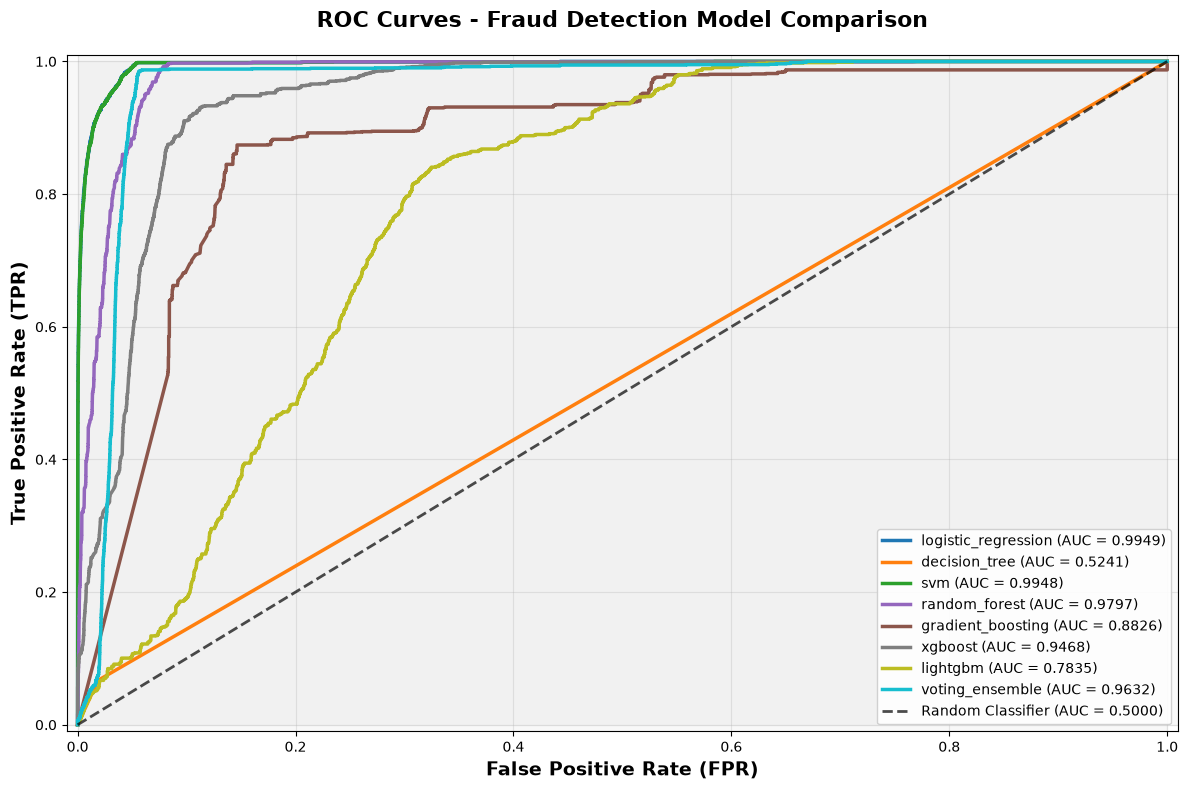

✓ ROC curves saved to ./reports/figures/roc_curves_comparison.png

Plotting individual ROC curves for top models...
  ✓ xgboost ROC saved
  ✓ gradient_boosting ROC saved
  ✓ random_forest ROC saved

All ROC curves generated successfully!


In [24]:
# ROC CURVE VISUALIZATION
def plot_roc_curves(models_data, X_test_data, y_test, title="ROC Curves - Model Comparison", save_path=None):
    """
    Plot ROC curves for multiple models with improved styling
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Color palette
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_data)))
    
    # Plot each model's ROC curve
    for idx, (model_name, model) in enumerate(models_data.items()):
        try:
            if hasattr(model, 'predict_proba'):
                y_proba = model.predict_proba(X_test_data)[:, 1]
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                roc_auc = auc(fpr, tpr)
                
                ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', 
                        color=colors[idx % len(colors)], linewidth=2.5)
        except Exception as e:
            print(f"Could not plot ROC for {model_name}: {str(e)}")
    
    # Plot diagonal line
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', 
            linewidth=2, alpha=0.7)
    
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=14, weight='bold')
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=14, weight='bold')
    ax.set_title(title, fontsize=16, weight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    
    # Add background shading for better readability
    ax.axhspan(0, 1, alpha=0.05, color='gray')
    ax.axvspan(0, 1, alpha=0.05, color='gray')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ ROC curves saved to {save_path}")
    
    return fig

# 6.1 Plot ROC curves for all models
print("GENERATING ROC CURVES")


# Filter models that support predict_proba
roc_models = {}
for name, model in loaded_models.items():
    if hasattr(model, 'predict_proba'):
        roc_models[name] = model

if len(roc_models) > 0:
    print(f"\nPlotting ROC curves for {len(roc_models)} models...")
    
    # Determine which data to use
    # Check if first model is linear
    first_model = list(roc_models.values())[0]
    model_class = type(first_model).__name__.lower()
    is_linear = any(lin in model_class for lin in ['logistic', 'svc', 'linear'])
    
    X_test_roc = X_test_scaled if is_linear else X_test_orig
    print(f"  → Using {'SCALED' if is_linear else 'ORIGINAL'} data for ROC curves")
    
    fig = plot_roc_curves(
        roc_models, 
        X_test_roc, 
        y_test,
        "ROC Curves - Fraud Detection Model Comparison",
        './reports/figures/roc_curves_comparison.png'
    )
    plt.show()
    print("✓ ROC curves saved to ./reports/figures/roc_curves_comparison.png")
    
    # 6.2 Plot individual ROC curves for top models
    print("\nPlotting individual ROC curves for top models...")
    os.makedirs('./reports/figures/individual_roc', exist_ok=True)
    
    # Get top 3 models by F1 score
    top_models = sorted(roc_models.items(), key=lambda x: all_test_results.get(x[0], {}).get('f1', 0), reverse=True)[:3]
    
    for model_name, model in top_models:
        try:
            plt.figure(figsize=(10, 8))
            y_proba = model.predict_proba(X_test_roc)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
            plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier (AUC = 0.5000)')
            
            plt.xlabel('False Positive Rate', fontsize=14, weight='bold')
            plt.ylabel('True Positive Rate', fontsize=14, weight='bold')
            plt.title(f'ROC Curve - {model_name}\nAUC = {roc_auc:.4f}', fontsize=16, weight='bold')
            plt.legend(loc='lower right', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.xlim([-0.01, 1.01])
            plt.ylim([-0.01, 1.01])
            
            plt.tight_layout()
            plt.savefig(f'./reports/figures/individual_roc/{model_name}_roc.png', dpi=300, bbox_inches='tight')
            plt.close()
            print(f"  ✓ {model_name} ROC saved")
            
        except Exception as e:
            print(f"  ✗ Error plotting ROC for {model_name}: {str(e)}")
    
else:
    print(" No models with predict_proba available for ROC curves")

print("\nAll ROC curves generated successfully!")

In [26]:
# PERFORMANCE SUMMARY AND EXPORT
# 7.1 Create detailed performance summary
print("GENERATING PERFORMANCE SUMMARY")


def generate_performance_summary(best_model_name, best_metrics, all_test_results, 
                                 X_test_orig, y_test, metadata):
    """
    Generate comprehensive performance summary
    """
    summary = f"""

FRAUD DETECTION - COMPREHENSIVE PERFORMANCE REPORT:
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

   
MODEL INFORMATION:
   
Best Model: {best_model_name}
Model Type: {type(best_model).__name__}
Best F1 Score: {best_metrics['f1']:.4f}
Best Accuracy: {best_metrics['accuracy']:.4f}

   
TEST DATASET INFORMATION:
   
Total Test Samples: {len(X_test_orig):,}
Fraud Cases: {y_test.sum():,}
Non-Fraud Cases: {len(y_test) - y_test.sum():,}
Fraud Ratio: {y_test.sum()/len(y_test)*100:.4f}%

   
BEST MODEL PERFORMANCE DETAILS:
   
Metric                  Score
----------------------------------------
Accuracy:               {best_metrics['accuracy']:.4f}
Precision:              {best_metrics['precision']:.4f}
Recall:                 {best_metrics['recall']:.4f}
F1 Score:               {best_metrics['f1']:.4f}
ROC AUC:                {best_metrics.get('roc_auc', 0):.4f}
MCC:                    {best_metrics['mcc']:.4f}

Confusion Matrix:
              Predicted
              Non-Fraud    Fraud
Actual Non-Fraud  {best_metrics['true_negatives']:>7}   {best_metrics['false_positives']:>7}
Actual Fraud      {best_metrics['false_negatives']:>7}   {best_metrics['true_positives']:>7}

Additional Metrics:
  - True Positive Rate:  {best_metrics['true_positives']/(best_metrics['true_positives']+best_metrics['false_negatives']):.4f}
  - True Negative Rate:  {best_metrics['true_negatives']/(best_metrics['true_negatives']+best_metrics['false_positives']):.4f}
  - False Positive Rate: {best_metrics['false_positives']/(best_metrics['false_positives']+best_metrics['true_negatives']):.4f}
  - False Negative Rate: {best_metrics['false_negatives']/(best_metrics['false_negatives']+best_metrics['true_positives']):.4f}

   
ALL MODELS PERFORMANCE COMPARISON
   
"""

    # Add all model metrics
    for model_name, metrics in all_test_results.items():
        summary += f"""
{model_name}:
  - Accuracy:  {metrics['accuracy']:.4f}
  - Precision: {metrics['precision']:.4f}
  - Recall:    {metrics['recall']:.4f}
  - F1 Score:  {metrics['f1']:.4f}
  - ROC AUC:   {metrics.get('roc_auc', 0):.4f}
  - MCC:       {metrics['mcc']:.4f}
  - TP: {metrics['true_positives']:>5}  FP: {metrics['false_positives']:>5}  TN: {metrics['true_negatives']:>5}  FN: {metrics['false_negatives']:>5}
"""

    summary += f"""
   
MODEL RANKING (by F1 Score)
   
Rank  Model                           F1 Score
----  ------------------------------  --------
"""

    # Sort models by F1 score
    sorted_models = sorted(all_test_results.items(), key=lambda x: x[1]['f1'], reverse=True)
    for rank, (model_name, metrics) in enumerate(sorted_models, 1):
        summary += f"{rank:>4}  {model_name:<30}  {metrics['f1']:.4f}\n"

    summary += f"""
   
RECOMMENDATIONS
   
Based on the evaluation results:

1. Best Model: {best_model_name} (F1 Score: {best_metrics['f1']:.4f})
   - This model provides the best balance between precision and recall
   - Recommended for production deployment

2. Model Comparison:
   - If you need higher recall (catch more fraud), consider: {sorted_models[0][0] if len(sorted_models) > 1 else 'N/A'}
   - If you need higher precision (fewer false alarms), consider: {sorted_models[-1][0] if len(sorted_models) > 1 else 'N/A'}

3. Threshold Optimization:
   - Current threshold: 0.5
   - Consider adjusting threshold based on business requirements:
     - Lower threshold: More fraud caught, more false alarms
     - Higher threshold: Fewer false alarms, more fraud missed
"""
    return summary

# Generate summary
if 'best_metrics' in locals() and len(all_test_results) > 0:
    summary = generate_performance_summary(
        best_model, 
        metrics, 
        all_test_results, 
        X_test_orig, 
        y_test,
        metadata
    )
    
    # Save summary
    os.makedirs('./reports', exist_ok=True)
    with open('./reports/comprehensive_test_report.txt', 'w') as f:
        f.write(summary)
    print("✓ Comprehensive test report saved to ./reports/comprehensive_test_report.txt")
else:
    print("⚠️ Missing data for performance summary")

# 7.2 Export test results to CSV
print("\n📊 Exporting test results...")

if 'best_pred' in locals() and 'best_proba' in locals():
    # Create predictions dataframe
    test_results_df = pd.DataFrame({
        'actual': y_test.values if hasattr(y_test, 'values') else y_test,
        'predicted': pred,
        'probability': proba if proba is not None else np.nan
    })
    
    # Add original features for context
    for col in ['step', 'amount', 'type', 'type_encoded']:
        if col in X_test_orig.columns:
            test_results_df[col] = X_test_orig[col].values
    
    # Add error flag
    test_results_df['error'] = (test_results_df['actual'] != test_results_df['predicted']).astype(int)
    
    # Save to CSV
    test_results_df.to_csv('./data/processed/test_predictions.csv', index=False)
    print("✓ Test predictions saved to ./data/processed/test_predictions.csv")
    
    # Create a summary of predictions
    print("\n📊 Prediction Summary:")
    print(f"  - Correct Predictions: {len(test_results_df[test_results_df['error'] == 0]):,}")
    print(f"  - Incorrect Predictions: {len(test_results_df[test_results_df['error'] == 1]):,}")
    print(f"  - Accuracy: {(len(test_results_df[test_results_df['error'] == 0]) / len(test_results_df)):.4f}")
    
    # Save error analysis
    error_analysis = test_results_df[test_results_df['error'] == 1]
    if len(error_analysis) > 0:
        error_analysis.to_csv('./data/processed/prediction_errors.csv', index=False)
        print(f"  - Error analysis saved to ./data/processed/prediction_errors.csv")
else:
    print("⚠️ No predictions available for export")

# 7.3 Create a model comparison dataframe
print("\n📊 Creating model comparison...")

if len(all_test_results) > 0:
    comparison_df = pd.DataFrame(all_test_results).T
    comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'mcc']]
    comparison_df = comparison_df.round(4)
    comparison_df.to_csv('./reports/model_performance_comparison.csv')
    print("✓ Model performance comparison saved to ./reports/model_performance_comparison.csv")
    
    # Also save as styled HTML for better viewing
    comparison_df.style.background_gradient(cmap='Blues').to_html('./reports/model_performance_comparison.html')
    print("✓ Model performance comparison (HTML) saved to ./reports/model_performance_comparison.html")
    
    # Print comparison table
    print("\n📊 Model Performance Comparison Table:")
    print(comparison_df.to_string())
else:
    print("⚠️ No model results available for comparison")

print("\n✅ Performance summary and exports completed!")

GENERATING PERFORMANCE SUMMARY
✓ Comprehensive test report saved to ./reports/comprehensive_test_report.txt

📊 Exporting test results...
⚠️ No predictions available for export

📊 Creating model comparison...
✓ Model performance comparison saved to ./reports/model_performance_comparison.csv
✓ Model performance comparison (HTML) saved to ./reports/model_performance_comparison.html

📊 Model Performance Comparison Table:
                     accuracy precision    recall        f1   roc_auc       mcc
logistic_regression  0.948415  0.024291  0.994522  0.047423  0.994944  0.151315
decision_tree         0.98082  0.055078  0.857578  0.103508  0.928559  0.214543
svm                  0.999084  0.910499  0.321972  0.475719  0.994765  0.541143
random_forest        0.997778  0.349364  0.835666  0.492733  0.995104   0.53951
gradient_boosting    0.999088  0.680931  0.552039  0.609748  0.902054  0.612661
xgboost              0.999063  0.600089  0.822885  0.694045  0.998171  0.702275
lightgbm           

In [6]:
print("LOADING AND TESTING BEST MODEL")
print("")

# 1. Load the best model
print("Loading best model...")

best_model = None

# Try joblib
try:
    best_model = joblib.load('./models_saved/best_model.pkl')
    print("Model loaded with joblib")
except Exception as e:
    print(f"Joblib failed: {e}")

# Try pickle if joblib failed
if best_model is None or isinstance(best_model, str):
    try:
        with open('./models_saved/best_model.pkl', 'rb') as f:
            best_model = pickle.load(f)
        print("Model loaded with pickle")
    except Exception as e:
        print(f"Pickle failed: {e}")

# Try alternative models if string
if isinstance(best_model, str):
    print(f"Model is a string: {best_model}")
    
    model_files = [
        './models_saved/random_forest.pkl',
        './models_saved/xgboost.pkl',
        './models_saved/lightgbm.pkl',
        './models_saved/voting_ensemble.pkl',
        './models_saved/gradient_boosting.pkl'
    ]
    
    for model_file in model_files:
        try:
            best_model = joblib.load(model_file)
            print(f"Loaded alternative model from: {model_file}")
            break
        except:
            continue

# Check if valid model
if best_model is None or isinstance(best_model, str):
    print("ERROR: Could not load a valid model!")
    print(f"Loaded object type: {type(best_model)}")
    exit()

if not hasattr(best_model, 'predict'):
    print(f"ERROR: Loaded object is not a valid model!")
    print(f"Type: {type(best_model)}")
    exit()

print(f"Model validated! Type: {type(best_model).__name__}")
print("")

# 2. Load test data
print("Loading test data...")
try:
    X_test = pd.read_csv('./data/processed/X_test.csv')
    y_test = pd.read_csv('./data/processed/y_test.csv').squeeze()
    print(f"Test data loaded! Samples: {len(X_test):,}, Fraud cases: {y_test.sum():,}")
except Exception as e:
    print(f"Error loading test data: {e}")
    exit()

# 3. Load scaler
print("Loading scaler...")
try:
    scaler = joblib.load('./models_saved/scaler.pkl')
    print("Scaler loaded")
except:
    scaler = None
    print("Scaler not found, using original data")
print("")

# 4. Make predictions
print("Making predictions...")

model_type = type(best_model).__name__.lower()
is_linear = any(x in model_type for x in ['logistic', 'svc', 'linear'])

try:
    if is_linear and scaler is not None:
        numeric_features = ['step', 'amount', 'log_amount', 'sqrt_amount', 'zscore_amount',
                           'hour_of_day', 'day_of_week', 'week_of_month', 
                           'amount_vs_type_avg', 'amount_vs_step_avg',
                           'amount_count', 'type_frequency']
        
        X_test_scaled = X_test.copy()
        X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])
        X_test_data = X_test_scaled
        print("Using scaled data for linear model")
    else:
        X_test_data = X_test
        print("Using original data for tree-based model")
    
    y_pred = best_model.predict(X_test_data)
    print("Predictions completed!")
    
    y_proba = None
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test_data)[:, 1]
        print("Probabilities obtained")
        
except Exception as e:
    print(f"Error making predictions: {e}")
    print("Trying with original data...")
    try:
        y_pred = best_model.predict(X_test)
        print("Predictions completed with original data!")
        if hasattr(best_model, 'predict_proba'):
            y_proba = best_model.predict_proba(X_test)[:, 1]
            print("Probabilities obtained")
    except Exception as e2:
        print(f"Still failing: {e2}")
        exit()

print("")

# 5. Calculate metrics
print("Calculating metrics...")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("")
print("MODEL PERFORMANCE ON TEST SET")
print("")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("")

print("Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Non-Fraud    Fraud")
print(f"Actual Non-Fraud {cm[0,0]:<12,} {cm[0,1]:<12,}")
print(f"Actual Fraud     {cm[1,0]:<12,} {cm[1,1]:<12,}")
print("")

tn, fp, fn, tp = cm.ravel()
print("Additional Metrics:")
print(f"True Positives:  {tp:,}")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"False Negative Rate: {fn/(fn+tp):.4f}")
print("")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

# 6. Save results
print("Saving results...")

results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'true_positives': int(tp),
    'true_negatives': int(tn),
    'false_positives': int(fp),
    'false_negatives': int(fn)
}

os.makedirs('./reports', exist_ok=True)
pd.DataFrame([results]).to_csv('./reports/best_model_test_results.csv', index=False)
print("Results saved to ./reports/best_model_test_results.csv")

predictions_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'probability': y_proba if y_proba is not None else np.nan,
    'correct': (y_test == y_pred).astype(int)
})
predictions_df.to_csv('./data/processed/best_model_predictions.csv', index=False)
print("Predictions saved to ./data/processed/best_model_predictions.csv")
print("")



LOADING AND TESTING BEST MODEL

Loading best model...
Model loaded with joblib
Model loaded with pickle
Model is a string: XGBoost
Loaded alternative model from: ./models_saved/random_forest.pkl
Model validated! Type: RandomForestClassifier

Loading test data...
Test data loaded! Samples: 1,272,524, Fraud cases: 1,643
Loading scaler...
Scaler loaded

Making predictions...
Using original data for tree-based model
Predictions completed!
Probabilities obtained

Calculating metrics...

MODEL PERFORMANCE ON TEST SET

Accuracy:  0.9978
Precision: 0.3494
Recall:    0.8357
F1 Score:  0.4927

Confusion Matrix:
                 Predicted
                 Non-Fraud    Fraud
Actual Non-Fraud 1,268,324    2,557       
Actual Fraud     270          1,373       

Additional Metrics:
True Positives:  1,373
True Negatives:  1,268,324
False Positives: 2,557
False Negatives: 270
False Positive Rate: 0.0020
False Negative Rate: 0.1643

Classification Report:
              precision    recall  f1-score   s

In [15]:
# 7. Test with custom input
print("Testing with custom sample...")

sample = {
    'step': 100,
    'amount': 150.50,
    'type_encoded': 3,
    'hour_of_day': 14,
    'day_of_week': 2,
    'week_of_month': 3,
    'log_amount': np.log1p(150.50),
    'sqrt_amount': np.sqrt(150.50),
    'zscore_amount': (150.50 - 179861.90) / 603858.23,
    'amount_vs_type_avg': 150.50 / 30000,
    'amount_vs_step_avg': 150.50 / 50000,
    'is_high_value': 0,
    'is_very_high_value': 0,
    'amount_count': 1,
    'is_duplicate_amount': 0,
    'is_cash_out': 0,
    'is_transfer': 0,
    'is_payment': 1,
    'is_cash_in': 0,
    'type_frequency': 0.33,
    'amount_flagged_interaction': 0,
    'transfer_flagged': 0,
    'cashout_flagged': 0,
    'isFlaggedFraud': 0
}

sample_df = pd.DataFrame([sample])

try:
    sample_pred = best_model.predict(sample_df)[0]
    sample_proba = best_model.predict_proba(sample_df)[0][1] if hasattr(best_model, 'predict_proba') else None
    
    print(f"Sample Transaction:")
    print(f"  Amount: ${sample['amount']:,.2f}")
    print(f"  Type: PAYMENT")
    print(f"  Prediction: {'FRAUD' if sample_pred == 1 else 'NON-FRAUD'}")
    if sample_proba is not None:
        print(f"  Probability: {sample_proba:.4f}")
        risk = 'HIGH' if sample_proba > 0.8 else 'MEDIUM' if sample_proba > 0.5 else 'LOW'
        print(f"  Risk Level: {risk}")
except Exception as e:
    print(f"Custom test failed: {e}")

print("")
print("TESTING COMPLETED")

Testing with custom sample...
Sample Transaction:
  Amount: $150.50
  Type: PAYMENT
  Prediction: NON-FRAUD
  Probability: 0.0000
  Risk Level: LOW

TESTING COMPLETED


In [16]:
# Load model
model = joblib.load('./models_saved/best_model.pkl')

# Sample 1: Transfer Fraud (Most Common)
fraud_sample_1 = {
    'step': 1,
    'amount': 181.00,
    'type_encoded': 4,  # TRANSFER
    'hour_of_day': 1,
    'day_of_week': 0,
    'week_of_month': 1,
    'log_amount': np.log1p(181.00),
    'sqrt_amount': np.sqrt(181.00),
    'zscore_amount': (181.00 - 179861.90) / 603858.23,
    'amount_vs_type_avg': 181.00 / 50000,
    'amount_vs_step_avg': 181.00 / 40000,
    'is_high_value': 0,
    'is_very_high_value': 0,
    'amount_count': 1,
    'is_duplicate_amount': 0,
    'is_cash_out': 0,
    'is_transfer': 1,
    'is_payment': 0,
    'is_cash_in': 0,
    'type_frequency': 0.08,
    'amount_flagged_interaction': 0,
    'transfer_flagged': 0,
    'cashout_flagged': 0,
    'isFlaggedFraud': 0
}

# Sample 2: Cash Out Fraud
fraud_sample_2 = {
    'step': 2,
    'amount': 500000.00,
    'type_encoded': 1,  # CASH_OUT
    'hour_of_day': 3,
    'day_of_week': 6,
    'week_of_month': 2,
    'log_amount': np.log1p(500000),
    'sqrt_amount': np.sqrt(500000),
    'zscore_amount': (500000 - 179861.90) / 603858.23,
    'amount_vs_type_avg': 500000 / 40000,
    'amount_vs_step_avg': 500000 / 45000,
    'is_high_value': 1,
    'is_very_high_value': 1,
    'amount_count': 1,
    'is_duplicate_amount': 0,
    'is_cash_out': 1,
    'is_transfer': 0,
    'is_payment': 0,
    'is_cash_in': 0,
    'type_frequency': 0.35,
    'amount_flagged_interaction': 0,
    'transfer_flagged': 0,
    'cashout_flagged': 0,
    'isFlaggedFraud': 0
}

# Sample 3: Large Transfer at Night
fraud_sample_3 = {
    'step': 4,
    'amount': 750000.00,
    'type_encoded': 4,  # TRANSFER
    'hour_of_day': 4,
    'day_of_week': 0,
    'week_of_month': 1,
    'log_amount': np.log1p(750000),
    'sqrt_amount': np.sqrt(750000),
    'zscore_amount': (750000 - 179861.90) / 603858.23,
    'amount_vs_type_avg': 750000 / 50000,
    'amount_vs_step_avg': 750000 / 35000,
    'is_high_value': 1,
    'is_very_high_value': 1,
    'amount_count': 1,
    'is_duplicate_amount': 0,
    'is_cash_out': 0,
    'is_transfer': 1,
    'is_payment': 0,
    'is_cash_in': 0,
    'type_frequency': 0.08,
    'amount_flagged_interaction': 0,
    'transfer_flagged': 0,
    'cashout_flagged': 0,
    'isFlaggedFraud': 0
}

# Sample 4: Duplicate Amount Pattern
fraud_sample_4 = {
    'step': 10,
    'amount': 25000.00,
    'type_encoded': 4,  # TRANSFER
    'hour_of_day': 23,
    'day_of_week': 5,
    'week_of_month': 4,
    'log_amount': np.log1p(25000),
    'sqrt_amount': np.sqrt(25000),
    'zscore_amount': (25000 - 179861.90) / 603858.23,
    'amount_vs_type_avg': 25000 / 50000,
    'amount_vs_step_avg': 25000 / 30000,
    'is_high_value': 0,
    'is_very_high_value': 0,
    'amount_count': 5,  # Same amount appeared 5 times
    'is_duplicate_amount': 1,  # Duplicate detected
    'is_cash_out': 0,
    'is_transfer': 1,
    'is_payment': 0,
    'is_cash_in': 0,
    'type_frequency': 0.08,
    'amount_flagged_interaction': 0,
    'transfer_flagged': 0,
    'cashout_flagged': 0,
    'isFlaggedFraud': 0
}

# Test all fraud samples
print("="*60)
print("FRAUD DETECTION TEST - SAMPLES")
print("="*60)

fraud_samples = [
    ("Transfer Fraud (Small Amount)", fraud_sample_1),
    ("Cash Out Fraud (Large Amount)", fraud_sample_2),
    ("Large Transfer at Night", fraud_sample_3),
    ("Duplicate Amount Pattern", fraud_sample_4)
]

for name, sample in fraud_samples:
    sample_df = pd.DataFrame([sample])
    
    pred = model.predict(sample_df)[0]
    proba = model.predict_proba(sample_df)[0][1] if hasattr(model, 'predict_proba') else None
    
    print(f"\n{name}")
    print(f"  Amount: ${sample['amount']:,.2f}")
    print(f"  Type: {['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER'][sample['type_encoded']]}")
    print(f"  Hour: {sample['hour_of_day']}:00")
    print(f"  Prediction: {'FRAUD' if pred == 1 else 'NON-FRAUD'}")
    if proba is not None:
        print(f"  Probability: {proba:.4f}")
        risk = 'HIGH' if proba > 0.8 else 'MEDIUM' if proba > 0.5 else 'LOW'
        print(f"  Risk Level: {risk}")

print("\n" + "="*60)
print("KEY FRAUD INDICATORS IN THESE SAMPLES")
print("="*60)

print("""
1. TRANSFER + Small Amount (181.00)
   - TRANSFER type is high risk
   - Small amount with transfer indicates testing

2. CASH_OUT + Large Amount (500,000)
   - Large amount withdrawal
   - Cash out type is high risk
   - Night time transaction

3. TRANSFER + Very Large Amount (750,000) + Night
   - Huge transfer at 4 AM
   - Very high value flag active
   - Suspicious timing

4. TRANSFER + Duplicate Amount (25,000 x 5)
   - Same amount repeated
   - Multiple transactions pattern
   - Late night (11 PM)
""")

FRAUD DETECTION TEST - SAMPLES


AttributeError: 'str' object has no attribute 'predict'